In [3]:
import pandas as pd


# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Filtrar los clientes que suscribieron un depósito a término
clientes_con_deposito = df[df['y'] == 'yes']

# Calcular el monto promedio de balance
monto_promedio = clientes_con_deposito['balance'].mean()

# Tasa de interés efectiva anual (TEA) que paga el banco
TEA = 9.83 / 100  # Convertir a decimal

# Tasa de interés que cobra el banco
tasa_interes_banco = 15.75 / 100  # Convertir a decimal

# Calcular el beneficio del banco asociado a un verdadero positivo (TP)
P= monto_promedio * (tasa_interes_banco - TEA)

print(f'P: {P:.2f} euros')
# Definiciones iniciales
salario_hora_pesos = 8304  # salario por hora en pesos colombianos
tasa_conversion = 4808.10  # tasa de conversión de pesos colombianos a euros
duration = df['duration'].mean() 

# Convertir salario a euros
salario_hora_euros = salario_hora_pesos / tasa_conversion

# Calcular costo por segundo
costo_por_segundo = salario_hora_euros / 3600

# Calcular el costo de un falso positivo
CC = costo_por_segundo * duration

print(f"CC: {CC:.2f} euros")



P: 106.81 euros
CC: 0.12 euros


y
1    16123
0    11044
Name: count, dtype: int64
Epoch 1/50
849/849 [==============================] - 3s 2ms/step - loss: 0.6595 - accuracy: 0.6691 - val_loss: 1.4347 - val_accuracy: 0.3839
Epoch 2/50
849/849 [==============================] - 1s 2ms/step - loss: 0.5339 - accuracy: 0.7002 - val_loss: 1.3449 - val_accuracy: 0.3864
Epoch 3/50
849/849 [==============================] - 2s 2ms/step - loss: 0.5095 - accuracy: 0.7122 - val_loss: 1.2220 - val_accuracy: 0.4017
Epoch 4/50
849/849 [==============================] - 2s 2ms/step - loss: 0.5038 - accuracy: 0.7144 - val_loss: 1.2268 - val_accuracy: 0.4307
Epoch 5/50
849/849 [==============================] - 1s 2ms/step - loss: 0.4920 - accuracy: 0.7203 - val_loss: 1.3539 - val_accuracy: 0.3148
Epoch 6/50
849/849 [==============================] - 2s 2ms/step - loss: 0.4880 - accuracy: 0.7211 - val_loss: 1.2536 - val_accuracy: 0.3721
Epoch 7/50
849/849 [==============================] - 2s 2ms/step - loss: 0.4869 - accuracy: 0.721

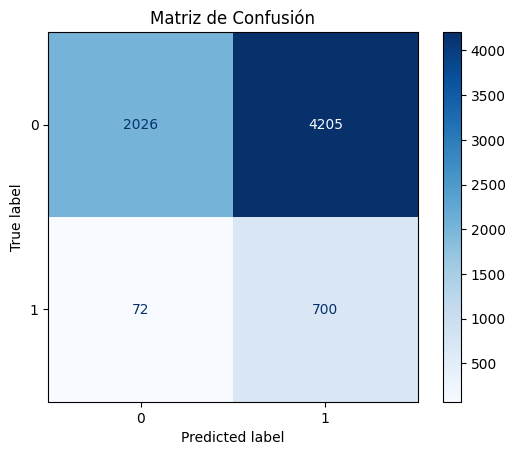

              precision    recall  f1-score   support

           0       0.97      0.33      0.49      6231
           1       0.14      0.91      0.25       772

    accuracy                           0.39      7003
   macro avg       0.55      0.62      0.37      7003
weighted avg       0.87      0.39      0.46      7003

Verdaderos Negativos (TN): 2026
Falsos Positivos (FP): 4205
Falsos Negativos (FN): 72
Verdaderos Positivos (TP): 700
Ingresos esperados (I): 66721.78 euros


In [24]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df = df[(df['age'] < 50)]
# Convertir las categorías a valores numéricos
cat_int_feats = ['default', 'housing', 'loan', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  # Primera capa oculta
model_layers = keras.layers.Dropout(0.5)(model_layers)  # Dropout
model_layers = keras.layers.BatchNormalization()(model_layers)  # Normalización por lotes
model_layers = keras.layers.Dense(64, activation='relu')(model_layers)  # Segunda capa oculta
model_layers = keras.layers.Dropout(0.5)(model_layers)  # Dropout
model_layers = keras.layers.BatchNormalization()(model_layers)  # Normalización por lotes
model_layers = keras.layers.Dense(32, activation='relu')(model_layers)  # Tercera capa oculta
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)  # Capa de salida

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
# Cálculo de class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds, class_weight=class_weights)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')


model.save('modeloproy2_3.keras')

y
1    4029
0    2917
Name: count, dtype: int64
Epoch 1/50
218/218 [==============================] - 2s 3ms/step - loss: 0.7588 - accuracy: 0.6480 - val_loss: 1.2279 - val_accuracy: 0.3709
Epoch 2/50
218/218 [==============================] - 0s 2ms/step - loss: 0.5394 - accuracy: 0.7052 - val_loss: 1.1949 - val_accuracy: 0.4580
Epoch 3/50
218/218 [==============================] - 0s 2ms/step - loss: 0.4978 - accuracy: 0.7339 - val_loss: 1.1774 - val_accuracy: 0.5365
Epoch 4/50
218/218 [==============================] - 0s 2ms/step - loss: 0.4859 - accuracy: 0.7502 - val_loss: 1.1651 - val_accuracy: 0.5408
Epoch 5/50
218/218 [==============================] - 0s 2ms/step - loss: 0.4614 - accuracy: 0.7698 - val_loss: 1.1333 - val_accuracy: 0.5604
Epoch 6/50
218/218 [==============================] - 0s 2ms/step - loss: 0.4509 - accuracy: 0.7774 - val_loss: 1.2368 - val_accuracy: 0.5169
Epoch 7/50
218/218 [==============================] - 0s 2ms/step - loss: 0.4548 - accuracy: 0.7692 

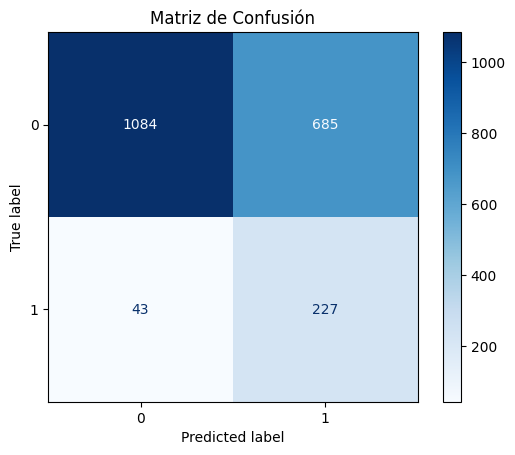

              precision    recall  f1-score   support

           0       0.96      0.61      0.75      1769
           1       0.25      0.84      0.38       270

    accuracy                           0.64      2039
   macro avg       0.61      0.73      0.57      2039
weighted avg       0.87      0.64      0.70      2039

Verdaderos Negativos (TN): 1084
Falsos Positivos (FP): 685
Falsos Negativos (FN): 43
Verdaderos Positivos (TP): 227
Ingresos esperados (I): 19674.83 euros


In [25]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df = df[(df['age'] >= 50)]
# Convertir las categorías a valores numéricos
cat_int_feats = ['default', 'housing', 'loan', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  # Primera capa oculta
model_layers = keras.layers.Dropout(0.5)(model_layers)  # Dropout
model_layers = keras.layers.BatchNormalization()(model_layers)  # Normalización por lotes
model_layers = keras.layers.Dense(64, activation='relu')(model_layers)  # Segunda capa oculta
model_layers = keras.layers.Dropout(0.5)(model_layers)  # Dropout
model_layers = keras.layers.BatchNormalization()(model_layers)  # Normalización por lotes
model_layers = keras.layers.Dense(32, activation='relu')(model_layers)  # Tercera capa oculta
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers)  # Capa de salida

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
# Cálculo de class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds, class_weight=class_weights)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')


model.save('modeloproy2_3.keras')